In [ ]:
import os, zipfile, shutil, random, time
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
FOOT_DIR = "/content/drive/MyDrive/FootpathVision"
ENC_ZIP  = os.path.join(FOOT_DIR, "Encroached.zip")
UNENC_ZIP = os.path.join(FOOT_DIR, "Unencroached.zip")

RAW_DIR   = "/content/foot_raw"
SPLIT_DIR = "/content/foot_split"
TRAIN_DIR = f"{SPLIT_DIR}/train"
VAL_DIR   = f"{SPLIT_DIR}/val"
TEST_DIR  = f"{SPLIT_DIR}/test"

for d in [RAW_DIR, SPLIT_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

for d in [RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(d, exist_ok=True)

In [ ]:
def extract_zip(zip_path, cls):
    dst = os.path.join(RAW_DIR, cls)
    os.makedirs(dst, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(dst)
    print(cls, "images:", len(os.listdir(dst)))

extract_zip(ENC_ZIP, "Encroached")
extract_zip(UNENC_ZIP, "Unencroached")

Encroached images: 719
Unencroached images: 519


In [ ]:
random.seed(42)

for cls in os.listdir(RAW_DIR):
    imgs = os.listdir(os.path.join(RAW_DIR, cls))
    random.shuffle(imgs)
    n = len(imgs)

    tr = imgs[:int(0.7*n)]
    va = imgs[int(0.7*n):int(0.85*n)]
    te = imgs[int(0.85*n):]

    for split, data in zip([TRAIN_DIR, VAL_DIR, TEST_DIR], [tr, va, te]):
        os.makedirs(os.path.join(split, cls), exist_ok=True)
        for img in data:
            shutil.copy(os.path.join(RAW_DIR, cls, img),
                        os.path.join(split, cls, img))

    print(cls, f"train={len(tr)} val={len(va)} test={len(te)}")

Encroached train=503 val=108 test=108
Unencroached train=363 val=78 test=78


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMG = 224
BATCH = 32
EPOCHS = 5

IM_MEAN = [0.485, 0.456, 0.406]
IM_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(IM_MEAN, IM_STD)
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize(IM_MEAN, IM_STD)
])

train_ds = datasets.ImageFolder(TRAIN_DIR, train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR, eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR, eval_tf)

train_loader = DataLoader(train_ds, BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, BATCH)
test_loader  = DataLoader(test_ds, BATCH)

class_names = train_ds.classes
num_classes = len(class_names)

Device: cpu


In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, n)
    def forward(self, x):
        return self.fc(self.net(x).flatten(1))

In [ ]:
import time

def train_model(model, name):
    model.to(device)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    tr_acc, va_acc, tr_loss, va_loss = [], [], [], []

    start_time = time.time()   # ⏱ START TIMER

    for ep in range(1, EPOCHS+1):
        print(f"\n[{name}] Epoch {ep}/{EPOCHS}")

        # -------- TRAIN --------
        model.train()
        correct = total = loss_sum = 0

        for x, y in tqdm(train_loader, desc="Training"):
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        tr_acc.append(correct / total)
        tr_loss.append(loss_sum / len(train_loader))

        # -------- VALIDATION --------
        model.eval()
        correct = total = loss_sum = 0

        with torch.no_grad():
            for x, y in tqdm(val_loader, desc="Validating"):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = loss_fn(out, y)

                loss_sum += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        va_acc.append(correct / total)
        va_loss.append(loss_sum / len(val_loader))

        print(f"Train Acc={tr_acc[-1]:.3f} | Val Acc={va_acc[-1]:.3f}")

    end_time = time.time()     # ⏱ END TIMER
    train_time = end_time - start_time

    print(f"[{name}] Total Training Time: {train_time:.2f} seconds")

    return tr_acc, va_acc, tr_loss, va_loss, train_time

In [ ]:
# 1. Custom CNN
custom = CustomCNN(num_classes)
c_tr_acc, c_va_acc, c_tr_loss, c_va_loss, c_time = train_model(custom, "Custom CNN")

# 2. ResNet Scratch
res_s = models.resnet18(weights=None)
res_s.fc = nn.Linear(res_s.fc.in_features, num_classes)
rs_tr_acc, rs_va_acc, rs_tr_loss, rs_va_loss, rs_time = train_model(res_s, "ResNet Scratch")

# 3. VGG Scratch
vgg_s = models.vgg16(weights=None)
vgg_s.classifier[6] = nn.Linear(4096, num_classes)
vs_tr_acc, vs_va_acc, vs_tr_loss, vs_va_loss, vs_time = train_model(vgg_s, "VGG Scratch")

# 4. ResNet Transfer
res_t = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in res_t.parameters(): p.requires_grad = False
res_t.fc = nn.Linear(res_t.fc.in_features, num_classes)
r_tr_acc, r_va_acc, r_tr_loss, r_va_loss, r_time = train_model(res_t, "ResNet Transfer")

# 5. VGG Transfer
vgg_t = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for p in vgg_t.features.parameters(): p.requires_grad = False
vgg_t.classifier[6] = nn.Linear(4096, num_classes)
v_tr_acc, v_va_acc, v_tr_loss, v_va_loss, v_time = train_model(vgg_t, "VGG Transfer")


[Custom CNN] Epoch 1/5


Training:   0%|          | 0/28 [00:00<?, ?it/s]

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Train Acc=0.575 | Val Acc=0.618

[Custom CNN] Epoch 2/5


Training:   0%|          | 0/28 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Train Acc=0.896 | Val Acc=0.882

[VGG Transfer] Epoch 5/5


Training:   0%|          | 0/28 [00:00<?, ?it/s]

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Train Acc=0.897 | Val Acc=0.898
[VGG Transfer] Total Training Time: 5251.75 seconds


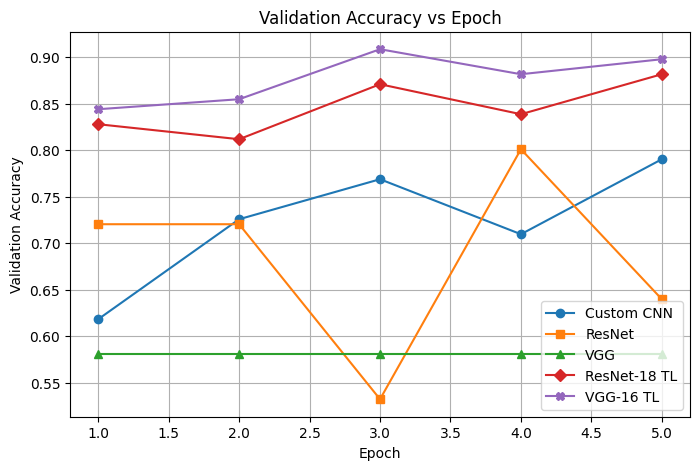

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, c_va_acc, '-o', label="Custom CNN")
plt.plot(epochs, rs_va_acc, '-s', label="ResNet")
plt.plot(epochs, vs_va_acc, '-^', label="VGG")
plt.plot(epochs, r_va_acc, '-D', label="ResNet-18 TL")
plt.plot(epochs, v_va_acc, '-X', label="VGG-16 TL")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


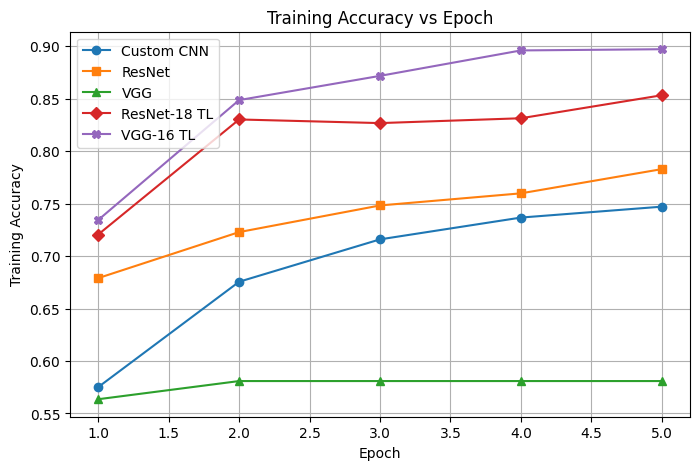

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(epochs, c_tr_acc, '-o', label="Custom CNN")
plt.plot(epochs, rs_tr_acc, '-s', label="ResNet")
plt.plot(epochs, vs_tr_acc, '-^', label="VGG")
plt.plot(epochs, r_tr_acc, '-D', label="ResNet-18 TL")
plt.plot(epochs, v_tr_acc, '-X', label="VGG-16 TL")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

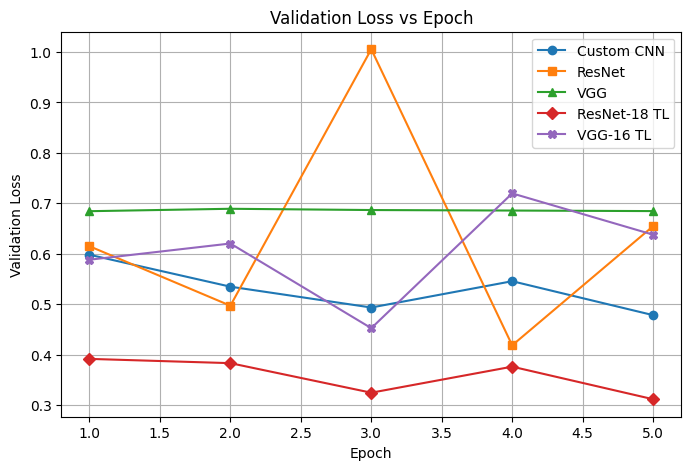

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(epochs, c_va_loss, '-o', label="Custom CNN")
plt.plot(epochs, rs_va_loss, '-s', label="ResNet")
plt.plot(epochs, vs_va_loss, '-^', label="VGG")
plt.plot(epochs, r_va_loss, '-D', label="ResNet-18 TL")
plt.plot(epochs, v_va_loss, '-X', label="VGG-16 TL")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

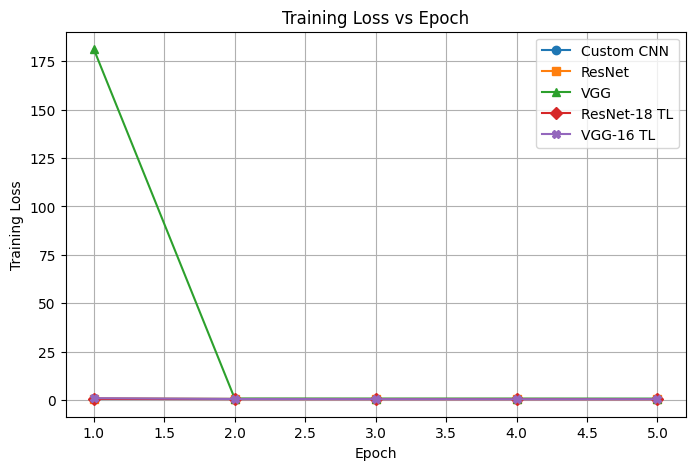

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(epochs, c_tr_loss, '-o', label="Custom CNN")
plt.plot(epochs, rs_tr_loss, '-s', label="ResNet")
plt.plot(epochs, vs_tr_loss, '-^', label="VGG")
plt.plot(epochs, r_tr_loss, '-D', label="ResNet-18 TL")
plt.plot(epochs, v_tr_loss, '-X', label="VGG-16 TL")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, model_name):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            out = model(x)
            preds = out.argmax(1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

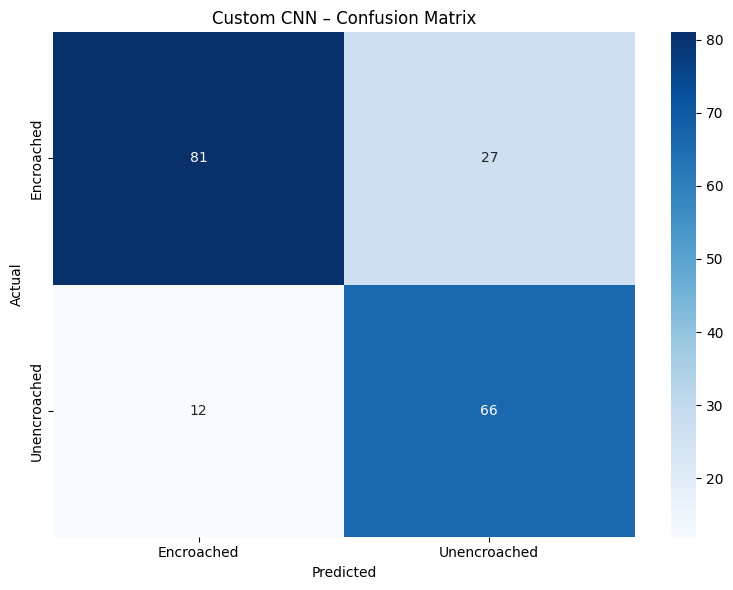

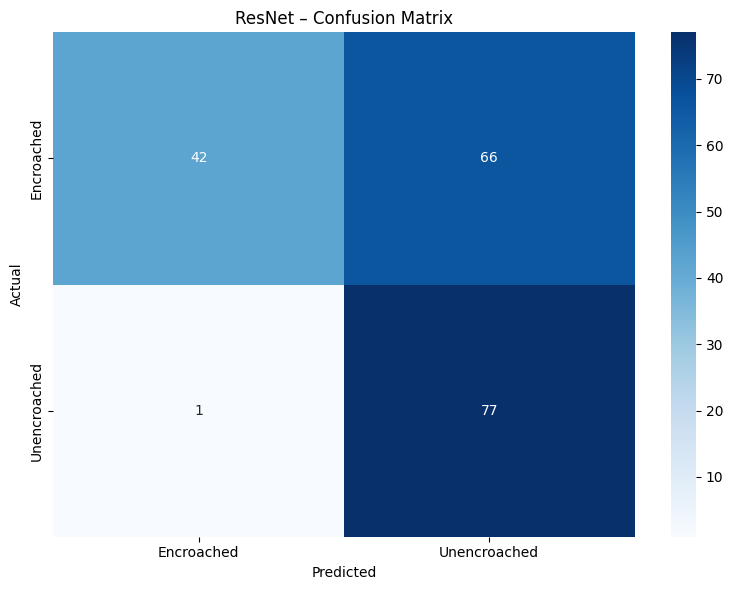

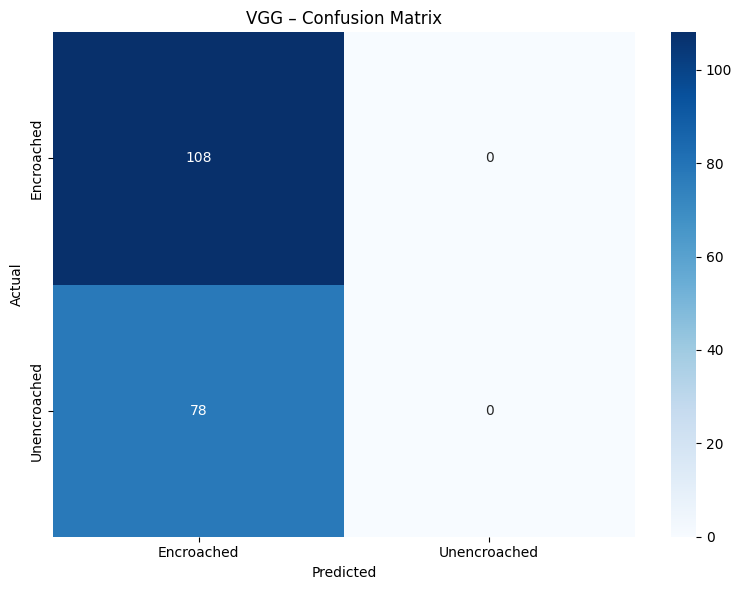

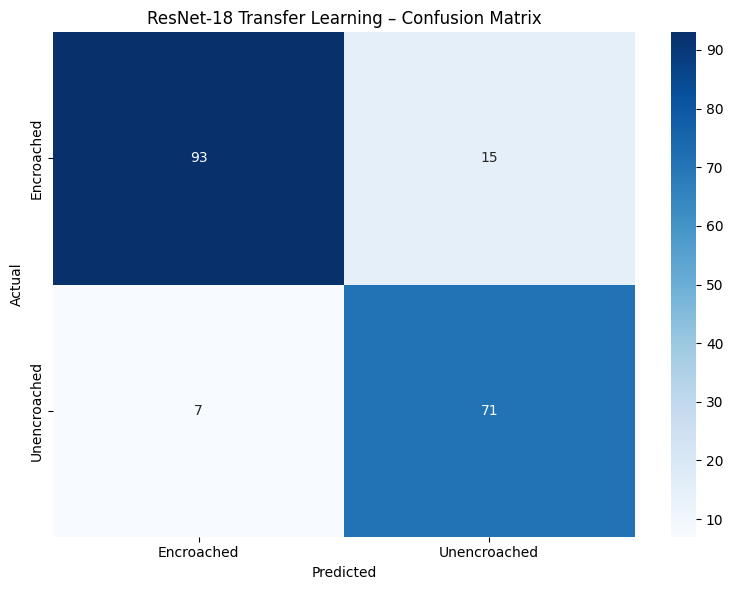

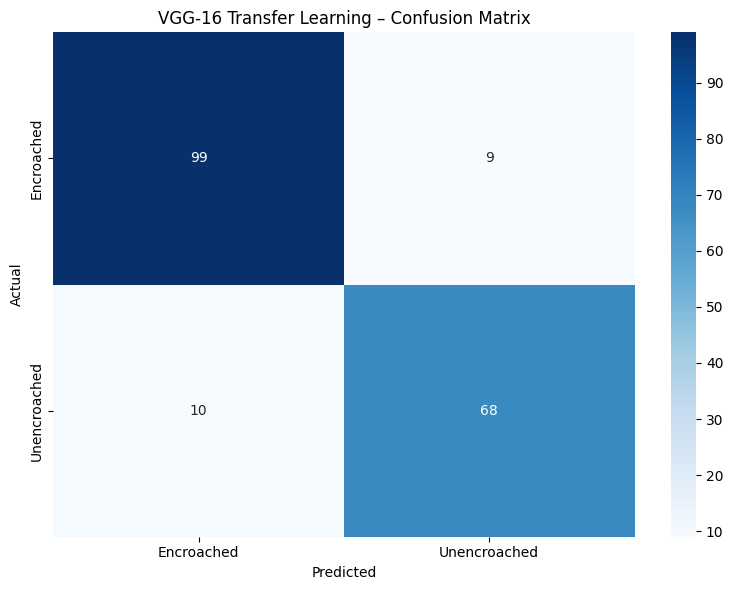

In [ ]:
# 1. Custom CNN
plot_confusion_matrix(custom, "Custom CNN")

# 2. ResNet Scratch
plot_confusion_matrix(res_s, "ResNet")

# 3. VGG Scratch
plot_confusion_matrix(vgg_s, "VGG")

# 4. ResNet Transfer Learning
plot_confusion_matrix(res_t, "ResNet-18 Transfer Learning")

# 5. VGG Transfer Learning
plot_confusion_matrix(vgg_t, "VGG-16 Transfer Learning")

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return acc, pr, rc, f1
# Custom CNN
yc, pc = get_preds(custom)

# ResNet Scratch
yrs, prs = get_preds(res_s)

# VGG Scratch
yvs, pvs = get_preds(vgg_s)

# ResNet Transfer
yrt, prt = get_preds(res_t)

# VGG Transfer
yvt, pvt = get_preds(vgg_t)
df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet-18 (Scratch)",
        "VGG-16 (Scratch)",
        "ResNet-18 (Transfer)",
        "VGG-16 (Transfer)"
    ],

    "Accuracy": [
        compute_metrics(yc, pc)[0],
        compute_metrics(yrs, prs)[0],
        compute_metrics(yvs, pvs)[0],
        compute_metrics(yrt, prt)[0],
        compute_metrics(yvt, pvt)[0]
    ],

    "Precision": [
        compute_metrics(yc, pc)[1],
        compute_metrics(yrs, prs)[1],
        compute_metrics(yvs, pvs)[1],
        compute_metrics(yrt, prt)[1],
        compute_metrics(yvt, pvt)[1]
    ],

    "Recall": [
        compute_metrics(yc, pc)[2],
        compute_metrics(yrs, prs)[2],
        compute_metrics(yvs, pvs)[2],
        compute_metrics(yrt, prt)[2],
        compute_metrics(yvt, pvt)[2]
    ],

    "F1-Score": [
        compute_metrics(yc, pc)[3],
        compute_metrics(yrs, prs)[3],
        compute_metrics(yvs, pvs)[3],
        compute_metrics(yrt, prt)[3],
        compute_metrics(yvt, pvt)[3]
    ],

    "Training Time (seconds)": [
        c_time,
        rs_time,
        vs_time,
        r_time,
        v_time
    ]
}).round(4)

df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (seconds)
0,Custom CNN,0.7903,0.8033,0.7903,0.7917,1756.3324
1,ResNet-18 (Scratch),0.6398,0.7929,0.6398,0.6152,2418.6744
2,VGG-16 (Scratch),0.5806,0.3371,0.5806,0.4266,11803.1790
3,ResNet-18 (Transfer),0.8817,0.8862,0.8817,0.8823,1575.6005
4,VGG-16 (Transfer),0.8978,0.8977,0.8978,0.8978,5251.7533
